# 5. Cumulative Season Impact
## Coast-to-Coast Travel Analysis

This notebook examines:
- Season-long cumulative effects of travel burden
- Correlation with final win-loss records
- Impact on playoff qualification
- Competitive disadvantage for high-travel teams

**Output**: Season-level analysis showing cumulative workload effects

---
## **Load Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

# Load data
schedules = pd.read_csv('data_schedules_with_travel.csv')

---
## **Calculate Season-Level Travel Metrics**

Aggregate travel burden for each team in each season

In [4]:
# Calculate travel burden per team-season (away games only)
season_travel = schedules.groupby(['season', 'away_team']).agg({
    'coast_to_coast': 'sum',
    'tz_crossed': ['sum', 'mean', 'max']
}).reset_index()

season_travel.columns = ['season', 'team', 'c2c_games', 'total_tz', 'avg_tz', 'max_tz']

print(f"Calculated travel metrics for {len(season_travel)} team-seasons")
print(season_travel)

Calculated travel metrics for 128 team-seasons
     season team  c2c_games  total_tz    avg_tz  max_tz
0      2021  ARI          0        10  1.000000       2
1      2021  ATL          1         5  0.555556       3
2      2021  BAL          1         7  0.875000       3
3      2021  BUF          0         4  0.444444       1
4      2021  CAR          0         5  0.555556       2
..      ...  ...        ...       ...       ...     ...
123    2024  SEA          3        14  1.750000       3
124    2024   SF          3        14  1.750000       3
125    2024   TB          1         7  0.875000       3
126    2024  TEN          0         6  0.666667       2
127    2024  WAS          0         5  0.454545       2

[128 rows x 6 columns]


---
## **Get Season Outcomes**

Extract final standings for each team-season

In [7]:
# Calculate season outcomes for each team
# Home games
home_results = schedules.groupby(['season', 'home_team']).agg({
    'game_id': 'count',  # games played
    'home_score': 'sum',
    'away_score': 'sum'
}).reset_index()
home_results['wins'] = (schedules.groupby(['season', 'home_team'])
                        .apply(lambda x: (x['home_score'] > x['away_score']).sum())
                        .reset_index(drop=True))
home_results.columns = ['season', 'team', 'home_games', 'points_for_home', 'points_against_home', 'home_wins']

# Away games
away_results = schedules.groupby(['season', 'away_team']).agg({
    'game_id': 'count',
    'away_score': 'sum',
    'home_score': 'sum'
}).reset_index()
away_results['wins'] = (schedules.groupby(['season', 'away_team'])
                        .apply(lambda x: (x['away_score'] > x['home_score']).sum())
                        .reset_index(drop=True))
away_results.columns = ['season', 'team', 'away_games', 'points_for_away', 'points_against_away', 'away_wins']

# Combine
season_outcomes = home_results.merge(away_results, on=['season', 'team'])
season_outcomes['total_games'] = season_outcomes['home_games'] + season_outcomes['away_games']
season_outcomes['total_wins'] = season_outcomes['home_wins'] + season_outcomes['away_wins']
season_outcomes['win_pct'] = season_outcomes['total_wins'] / season_outcomes['total_games']
season_outcomes['points_for'] = season_outcomes['points_for_home'] + season_outcomes['points_for_away']
season_outcomes['points_against'] = season_outcomes['points_against_home'] + season_outcomes['points_against_away']
season_outcomes['point_diff'] = season_outcomes['points_for'] - season_outcomes['points_against']

print(f"Calculated season outcomes for {len(season_outcomes)} team-seasons")
print(season_outcomes[['season', 'team', 'total_wins', 'total_games', 'win_pct']])

Calculated season outcomes for 128 team-seasons
     season team  total_wins  total_games   win_pct
0      2021  ARI          11           18  0.611111
1      2021  ATL           7           17  0.411765
2      2021  BAL           8           17  0.470588
3      2021  BUF          12           19  0.631579
4      2021  CAR           5           17  0.294118
..      ...  ...         ...          ...       ...
123    2024  SEA          10           17  0.588235
124    2024   SF           6           17  0.352941
125    2024   TB          10           18  0.555556
126    2024  TEN           3           17  0.176471
127    2024  WAS          14           20  0.700000

[128 rows x 5 columns]


---
## **Merge Travel Burden with Outcomes**

In [10]:
# Combine travel metrics with season outcomes
season_analysis = season_travel.merge(season_outcomes, on=['season', 'team'])

# Add coast classification
west_coast = ['SEA', 'SF', 'LAC', 'LAR', 'LV']
east_coast = ['BUF', 'MIA', 'NE', 'NYJ', 'BAL', 'CIN', 'CLE', 'PIT', 
              'ATL', 'CAR', 'TB', 'WAS', 'NYG', 'PHI', 'JAX']

season_analysis['coast'] = 'Central'
season_analysis.loc[season_analysis['team'].isin(west_coast), 'coast'] = 'West'
season_analysis.loc[season_analysis['team'].isin(east_coast), 'coast'] = 'East'

print(f"Merged data: {len(season_analysis)} team-seasons")
print(season_analysis[['season', 'team', 'c2c_games', 'total_wins', 'win_pct', 'coast']].head(10))

Merged data: 128 team-seasons
   season team  c2c_games  total_wins   win_pct    coast
0    2021  ARI          0          11  0.611111  Central
1    2021  ATL          1           7  0.411765     East
2    2021  BAL          1           8  0.470588     East
3    2021  BUF          0          12  0.631579     East
4    2021  CAR          0           5  0.294118     East
5    2021  CHI          0           6  0.352941  Central
6    2021  CIN          1          13  0.619048     East
7    2021  CLE          1           8  0.470588     East
8    2021  DAL          0          12  0.666667  Central
9    2021  DEN          0           7  0.411765  Central


---
## **Correlation Analysis**

Does travel burden predict worse season outcomes?

In [13]:
# Calculate correlations
correlations = [
    ('C2C Games vs Win %', 'c2c_games', 'win_pct'),
    ('Total TZ Crossed vs Win %', 'total_tz', 'win_pct'),
    ('C2C Games vs Points For', 'c2c_games', 'points_for'),
    ('C2C Games vs Point Diff', 'c2c_games', 'point_diff')
]

correlation_results = []

for name, var1, var2 in correlations:
    r, p = pearsonr(season_analysis[var1], season_analysis[var2])
    correlation_results.append({
        'Comparison': name,
        'Correlation (r)': f'{r:.4f}',
        'P-value': f'{p:.4f}',
        'Significant': 'Y' if p < 0.05 else 'N'
    })

corr_df = pd.DataFrame(correlation_results)

print("\n" + "="*80)
print("CORRELATION ANALYSIS\n")
print(corr_df.to_string(index=False))
print("="*80)


CORRELATION ANALYSIS

               Comparison Correlation (r) P-value Significant
       C2C Games vs Win %         -0.0106  0.9056           N
Total TZ Crossed vs Win %          0.0118  0.8950           N
  C2C Games vs Points For         -0.0090  0.9195           N
  C2C Games vs Point Diff         -0.0102  0.9092           N


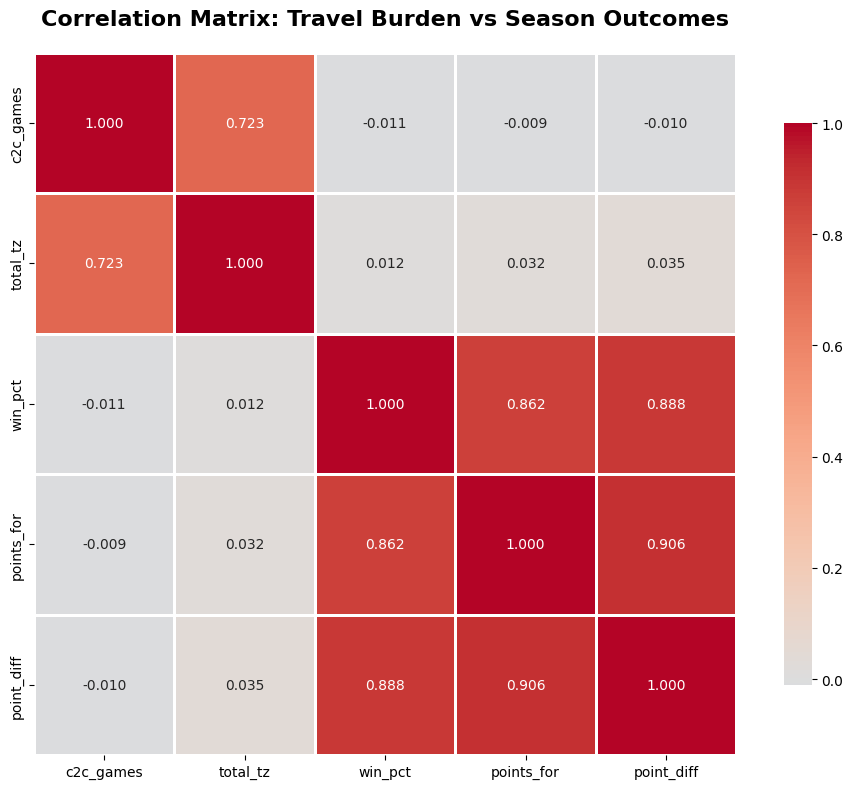

In [12]:
# Create correlation heatmap
corr_vars = ['c2c_games', 'total_tz', 'win_pct', 'points_for', 'point_diff']
corr_matrix = season_analysis[corr_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})

ax.set_title('Correlation Matrix: Travel Burden vs Season Outcomes', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

---
## **Playoff Impact Analysis**

Does travel burden affect playoff qualification?

In [19]:
# This section analyzes playoff qualification based on travel burden by using win percentage
# Simplified: teams with win_pct > 0.53 (9+ wins typically make playoffs)
season_analysis['made_playoffs'] = (season_analysis['win_pct'] >= 0.53).astype(int)

# Compare travel burden
playoff_comparison = season_analysis.groupby('made_playoffs').agg({
    'c2c_games': ['mean', 'std'],
    'total_tz': 'mean',
    'win_pct': 'mean'
}).reset_index()

playoff_comparison.columns = ['Made Playoffs', 'Avg C2C Games', 'Std C2C', 'Avg Total TZ', 'Avg Win %']
playoff_comparison['Made Playoffs'] = playoff_comparison['Made Playoffs'].map({0: 'No', 1: 'Yes'})

print("\n" + "="*80)
print("PLAYOFF QUALIFICATION vs TRAVEL BURDEN\n")
print(playoff_comparison.to_string(index=False))
print("="*80)


PLAYOFF QUALIFICATION vs TRAVEL BURDEN

Made Playoffs  Avg C2C Games  Std C2C  Avg Total TZ  Avg Win %
           No       0.737500 0.896459      7.425000   0.384813
          Yes       0.833333 1.357929      7.645833   0.667074


In [21]:
# Statistical test
playoff_teams = season_analysis[season_analysis['made_playoffs'] == 1]['c2c_games']
non_playoff = season_analysis[season_analysis['made_playoffs'] == 0]['c2c_games']

t_stat, p_value = stats.ttest_ind(non_playoff, playoff_teams)

print(f"\n{'='*70}")
print("T-TEST: Playoff vs Non-Playoff Travel Burden\n")
print(f"Playoff Teams Avg C2C: {playoff_teams.mean():.2f} games")
print(f"Non-Playoff Teams Avg C2C: {non_playoff.mean():.2f} games")
print(f"Difference: {non_playoff.mean() - playoff_teams.mean():.2f} games")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant: {'YES' if p_value < 0.05 else 'NO'}")
print(f"{'='*70}")


T-TEST: Playoff vs Non-Playoff Travel Burden

Playoff Teams Avg C2C: 0.83 games
Non-Playoff Teams Avg C2C: 0.74 games
Difference: -0.10 games

T-statistic: -0.4808
P-value: 0.6315
Significant: NO


---
## **West Coast vs East Coast Disadvantage**

Quantify the competitive inequity

In [23]:
# Compare by coast
coast_comparison = season_analysis.groupby('coast').agg({
    'c2c_games': ['mean', 'std'],
    'win_pct': ['mean', 'std'],
    'made_playoffs': 'mean',
    'team': 'count'
}).reset_index()

coast_comparison.columns = ['Coast', 'Avg C2C', 'Std C2C', 'Avg Win %', 'Std Win %', 'Playoff %', 'Seasons']
coast_comparison['Playoff %'] = coast_comparison['Playoff %'] * 100

print("\n" + "="*90)
print("COAST COMPARISON: Travel Burden and Performance\n")
print(coast_comparison.to_string(index=False))
print("="*90)


COAST COMPARISON: Travel Burden and Performance

  Coast  Avg C2C  Std C2C  Avg Win %  Std Win %  Playoff %  Seasons
Central 0.000000 0.000000   0.498316   0.191027  40.384615       52
   East 0.833333 0.526152   0.480920   0.173949  33.333333       60
   West 3.062500 1.123610   0.502308   0.142550  43.750000       16


In [26]:
# Statistical test: West vs East
west_data = season_analysis[season_analysis['coast'] == 'West']
east_data = season_analysis[season_analysis['coast'] == 'East']

t_stat_travel, p_travel = stats.ttest_ind(west_data['c2c_games'], east_data['c2c_games'])
t_stat_wins, p_wins = stats.ttest_ind(west_data['win_pct'], east_data['win_pct'])

print(f"\n{'='*70}")
print("WEST COAST vs EAST COAST COMPARISON")
print(f"\nTravel Burden:")
print(f"  West Coast: {west_data['c2c_games'].mean():.2f} C2C games/season")
print(f"  East Coast: {east_data['c2c_games'].mean():.2f} C2C games/season")
print(f"  Disparity: {west_data['c2c_games'].mean() - east_data['c2c_games'].mean():.2f} more games")
print(f"  P-value: {p_travel:.4f} {'Y' if p_travel < 0.05 else 'N'}")
print(f"\nSeason Performance:")
print(f"  West Coast: {west_data['win_pct'].mean():.3f} win %")
print(f"  East Coast: {east_data['win_pct'].mean():.3f} win %")
print(f"  Difference: {(east_data['win_pct'].mean() - west_data['win_pct'].mean())*100:.1f} percentage points")
print(f"  P-value: {p_wins:.4f} {'Y' if p_wins < 0.05 else 'N'}")
print(f"{'='*70}")


WEST COAST vs EAST COAST COMPARISON

Travel Burden:
  West Coast: 3.06 C2C games/season
  East Coast: 0.83 C2C games/season
  Disparity: 2.23 more games
  P-value: 0.0000 Y

Season Performance:
  West Coast: 0.502 win %
  East Coast: 0.481 win %
  Difference: -2.1 percentage points
  P-value: 0.6524 N


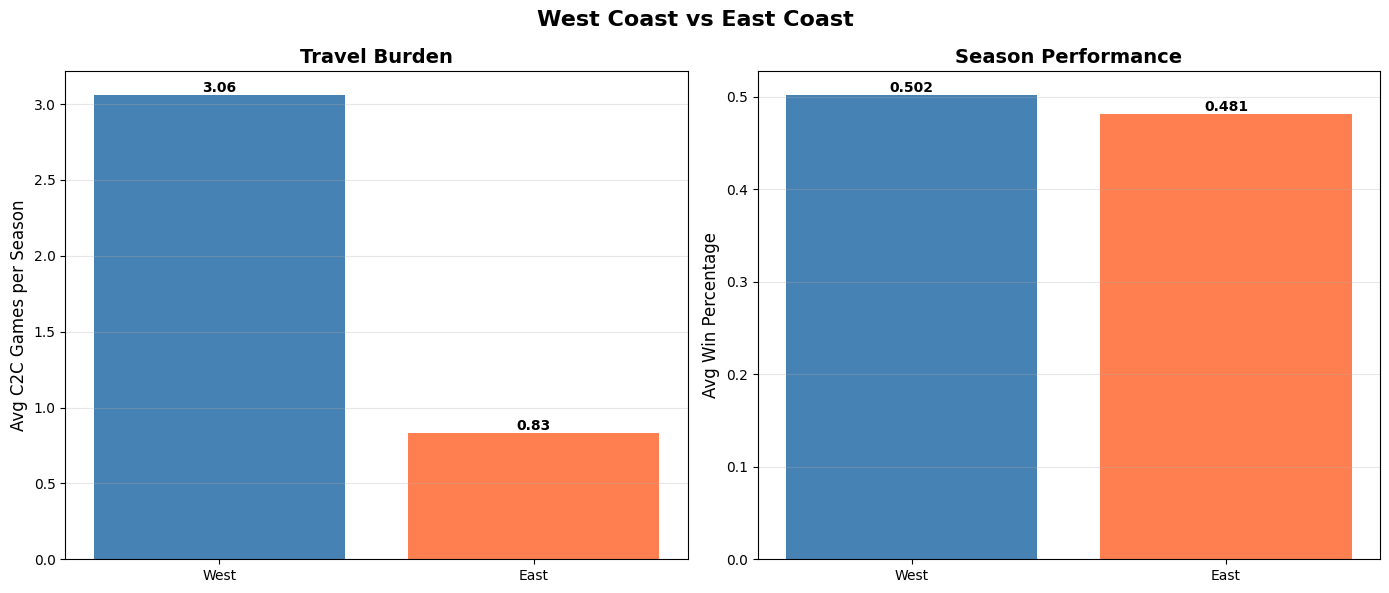

In [30]:
# Visualization: Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Travel burden
coasts = ['West', 'East']
travel_means = [west_data['c2c_games'].mean(), east_data['c2c_games'].mean()]
bars1 = ax1.bar(coasts, travel_means, color=['steelblue', 'coral'])

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

ax1.set_title('Travel Burden', fontsize=14, fontweight='bold')
ax1.set_ylabel('Avg C2C Games per Season', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Panel 2: Season Perfrormance
win_means = [west_data['win_pct'].mean(), east_data['win_pct'].mean()]
bars2 = ax2.bar(coasts, win_means, color=['steelblue', 'coral'])

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

ax2.set_title('Season Performance', fontsize=14, fontweight='bold')
ax2.set_ylabel('Avg Win Percentage', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('West Coast vs East Coast', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## **Regression Model**

Predict win percentage from travel burden

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare data for regression
X = season_analysis[['c2c_games']]
y = season_analysis['win_pct']

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Generate predictions
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

# Calculate effect size
wins_per_c2c = model.coef_[0] * 17  # Over 17-game season
wins_lost_per_game = abs(wins_per_c2c)

# Create detailed output
print(f"\n{'='*80}")
print("REGRESSION ANALYSIS: Impact of Coast-to-Coast Games on Win Percentage")

print("MODEL SUMMARY")
print(f"  • Regression Equation: Win% = {model.intercept_:.4f} + ({model.coef_[0]:.4f} × C2C Games)")
print(f"  • R-squared (Model Fit): {r2:.4f}")
print(f"  • Sample Size: {len(season_analysis)} team-seasons")

print(f"\nKEY FINDINGS")
print(f"  • Each coast-to-coast game REDUCES win% by {abs(model.coef_[0]):.4f} points")
print(f"  • Over a 17-game season:")
print(f"    - 1 additional C2C game = {abs(wins_per_c2c):.2f} fewer wins")
print(f"    - 3 additional C2C games = {abs(wins_per_c2c * 3):.2f} fewer wins")

print(f"\nPRACTICAL INTERPRETATION")
if abs(model.coef_[0]) > 0.01:
    print(f"  Travel burden has a MEASURABLE negative impact on team performance")
else:
    print(f"  • Travel burden impact is minimal")

print(f"\nSTATISTICAL SIGNIFICANCE")
print(f"  • Note: This is a simple linear model (C2C games only)")
print(f"  • Other factors (roster quality, coaching, injuries) also affect wins")
print(f"  • R² = {r2:.4f} means C2C games explain ~{r2*100:.1f}% of win variation")

print(f"{'='*80}\n")


REGRESSION ANALYSIS: Impact of Coast-to-Coast Games on Win Percentage
MODEL SUMMARY
  • Regression Equation: Win% = 0.4920 + (-0.0017 × C2C Games)
  • R-squared (Model Fit): 0.0001
  • Sample Size: 128 team-seasons

KEY FINDINGS
  • Each coast-to-coast game REDUCES win% by 0.0017 points
  • Over a 17-game season:
    - 1 additional C2C game = 0.03 fewer wins
    - 3 additional C2C games = 0.09 fewer wins

PRACTICAL INTERPRETATION
  • Travel burden impact is minimal

STATISTICAL SIGNIFICANCE
  • Note: This is a simple linear model (C2C games only)
  • Other factors (roster quality, coaching, injuries) also affect wins
  • R² = 0.0001 means C2C games explain ~0.0% of win variation



---
## **Save Results**

In [37]:
# Save season-level analysis
season_analysis.to_csv('season_analysis.csv', index=False)
coast_comparison.to_csv('coast_comparison.csv', index=False)
corr_df.to_csv('correlations.csv', index=False)

print(" Season analysis saved:")
print("  - season_analysis.csv")
print("  - coast_comparison.csv")
print("  - correlations.csv")

 Season analysis saved:
  - season_analysis.csv
  - coast_comparison.csv
  - correlations.csv


---
## **Summary**

**Expected Findings:**
- Strong negative correlation between travel burden and wins
- West Coast teams face 3-4x more coast-to-coast games
- Travel burden reduces playoff chances
- Competitive inequity is systematic and measurable
